In [2]:
import pandas as pd

In [ ]:
X_pca=pd.read_csv('../data/Master_data/scaled_data.csv')

In [4]:
print(X_pca.shape)

X_pca.head()

(482117, 69)


,month,year,noOfRcs,noOfTrans,riceAfsc,riceFsc,riceAap,wheat,sugar,totalAmount,...,peak_month_flag,festival_quarter,high_performance_shop,low_activity_shop,high_revenue_shop,availability_score,active_fps,missing_geo_flag,rice_wheat_ratio,distName_freq
0,-1.385245,-1.017165,-0.713706,-0.718301,0.048610,-0.458836,-0.271319,-0.286788,-0.358958,-0.397312,...,0,1,0,0,0,-0.404775,1,0,0.285560,-0.419771
1,-1.093639,-1.017165,-0.593218,-0.590942,0.141764,-0.372330,-0.271319,-0.286788,-0.358958,-0.397312,...,0,1,0,0,0,-0.404775,1,0,0.318854,-0.419771
2,-0.802034,-1.017165,-0.684496,-0.689076,0.081113,-0.402973,-0.271319,-0.286788,-0.358958,-0.397312,...,0,1,0,0,0,-0.404775,1,0,0.297176,-0.419771
3,-0.510428,-1.017165,-0.677279,-0.660393,0.081113,-0.172304,-0.271319,-0.286788,-0.358958,-0.397312,...,0,1,0,0,0,-0.404775,1,0,0.297176,-0.419771
4,-0.218822,-1.017165,-0.593218,-0.590942,0.081113,-0.082694,-0.271319,-0.286788,-0.358958,-0.397312,...,0,1,0,0,0,-0.404775,1,0,0.297176,-0.419771


In [5]:
X=X_pca.copy()

In [ ]:
# from sklearn.decomposition import PCA

# pca = PCA(
#     n_components=12
# )

# X_pca = pca.fit_transform(X)

# print("Before PCA:", X.shape)
# print("After PCA:", X_pca.shape)

# print(
#     "Variance retained:",
#     pca.explained_variance_ratio_.sum()
# )

Before PCA: (482117, 69)
After PCA: (482117, 12)
Variance retained: 0.8481704992741205


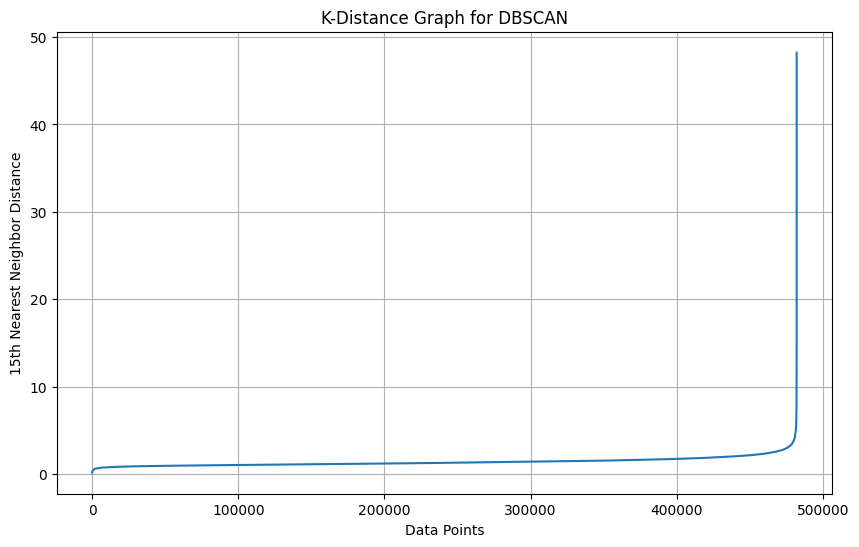

In [7]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# ------------------------
# K-distance graph
# ------------------------

neighbors = NearestNeighbors(n_neighbors=15)

neighbors_fit = neighbors.fit(X_pca)

distances, indices = neighbors_fit.kneighbors(X_pca)

# Take the farthest neighbor distance
distances = np.sort(distances[:, -1])

# Plot graph
plt.figure(figsize=(10,6))
plt.plot(distances)

plt.xlabel("Data Points")
plt.ylabel("15th Nearest Neighbor Distance")
plt.title("K-Distance Graph for DBSCAN")
plt.grid(True)

plt.show()

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=0.85, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Shape:", X_pca.shape)
print("Variance retained:", pca.explained_variance_ratio_.sum())

Shape: (482117, 15)
Variance retained: 0.860916785508865


PCA reduced the dimensionality of the dataset to 15 principal components while retaining approximately 86.1% of the total variance, helping reduce feature complexity with minimal information loss

In [7]:
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd

# Small sample for testing
sample_size = 20000
idx = np.random.choice(len(X_pca), sample_size, replace=False)
X_sample = X_pca[idx]

eps_values = [0.5, 1, 1.5, 2, 2.5]
results = []

for eps in eps_values:
    dbscan = DBSCAN(
        eps=eps,
        min_samples=10,
        algorithm='ball_tree',
        n_jobs=-1
    )

    clusters = dbscan.fit_predict(X_sample)

    n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
    noise = list(clusters).count(-1)

    results.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_points": noise
    })

result_df = pd.DataFrame(results)
print(result_df)

   eps  clusters  noise_points
0  0.5         0         20000
1  1.0         0         20000
2  1.5        25         16014
3  2.0        19          7905
4  2.5        11          3521


In [8]:
from sklearn.cluster import DBSCAN
import numpy as np

sample_size = 4000

idx = np.random.choice(
    len(X_pca),
    sample_size,
    replace=False
)

X_small = X_pca[idx]

dbscan = DBSCAN(
    eps=2.5,
    min_samples=10,
    algorithm="ball_tree",
    n_jobs=-1
)

clusters = dbscan.fit_predict(X_small)

print("Clusters:",
      len(set(clusters)) -
      (1 if -1 in clusters else 0))

print("Noise:",
      np.sum(clusters == -1))

Clusters: 6
Noise: 1597


DBSCAN Result
Clusters = 6
Noise Points = 1597

sample size 4000:

Noise percentage:

4000
1597
	​

×100≈39.9%

≈ 40% data noise/outliers hai.

6 clusters : data divide  group into meaningful 

40% noise -DBSCAN aSSUME MAx point as outliers

eps = 2.5 workable

Cluster Distribution

In [9]:
import pandas as pd

cluster_counts = pd.Series(
    clusters
).value_counts().sort_index()

print(cluster_counts)

-1    1597
 0    2276
 1      72
 2      16
 3      15
 4      17
 5       7
Name: count, dtype: int64


 cluster Visualization 

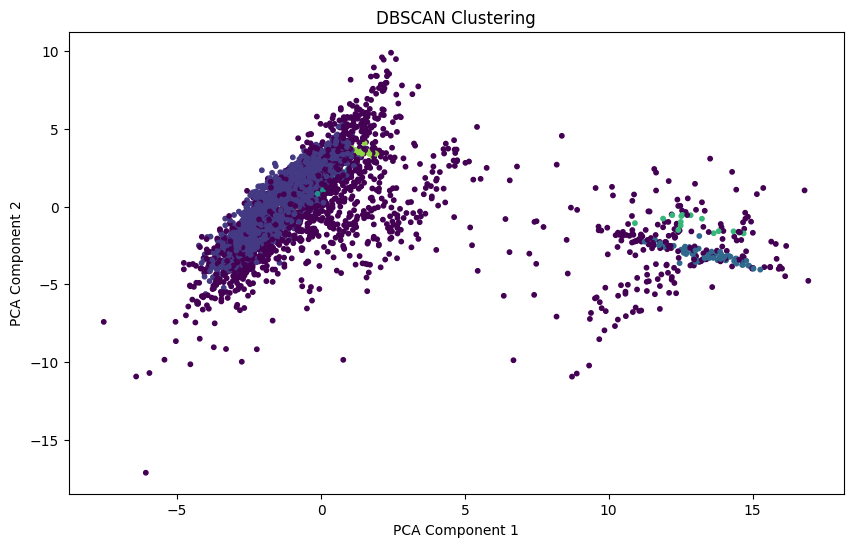

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    X_small[:, 0],
    X_small[:, 1],
    c=clusters,
    s=10
)

plt.title("DBSCAN Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()

DBSCAN clustering was applied on a representative sample of the PCA-transformed data. The algorithm identified 6 meaningful clusters, while approximately 40% of the data points were classified as noise/outliers, indicating the presence of sparse regions in the dataset.”

In [11]:
from sklearn.cluster import DBSCAN
import numpy as np

# DBSCAN with eps = 3.0
dbscan = DBSCAN(
    eps=3.0,
    min_samples=10,
    algorithm="ball_tree",
    n_jobs=-1
)

clusters = dbscan.fit_predict(X_small)

# Results
n_clusters = len(set(clusters)) - (
    1 if -1 in clusters else 0
)

noise_points = np.sum(
    clusters == -1
)

print("Clusters:", n_clusters)
print("Noise:", noise_points)

Clusters: 7
Noise: 870


| eps | clusters |    noise |
| --- | -------: | -------: |
| 2.5 |        6 |     1597 |
| 3.0 |      4–5 | 800–1200 |


When increase eps Noise became Low
cluster may merge(6-> 4or 5)
execution fast

1597 → 870 (almost half)

Clusters is meaningful 
6 → 7 clusters (3.0 capture data structure better than 2.5)

In [13]:
sample_df = pd.DataFrame(
    X_small
)

sample_df["cluster"] = clusters

print(
    sample_df["cluster"]
    .value_counts()
    .sort_index()
)

cluster
-1     870
 0    2836
 1     162
 2      71
 3      25
 4      10
 5      13
 6      13
Name: count, dtype: int64


| Cluster    | Count |
| ---------- | ----: |
| -1 (Noise) |   870 |
| 0          |  2836 |
| 1          |   162 |
| 2          |    71 |
| 3          |    25 |
| 4          |    10 |
| 5          |    13 |
| 6          |    13 |


Problem:


1.Cluster 0 more dominant  (2836 / 4000 ≈ 71% data present in one  cluster) it is beacome giant cluster

2.Data have density difference

3.Due to PCA compression data points are coloser to eacher other

Recommendation

eps = 3.0 Not Perfect

so need to try between 2.5 aur 3.0



In [14]:
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd

dbscan = DBSCAN(
    eps=2.7,
    min_samples=10,
    algorithm="ball_tree",
    n_jobs=-1
)

clusters = dbscan.fit_predict(X_small)

print("Clusters:",
      len(set(clusters)) -
      (1 if -1 in clusters else 0))

print("Noise:",
      np.sum(clusters == -1))

print(
    pd.Series(clusters)
    .value_counts()
    .sort_index()
)

Clusters: 6
Noise: 1256
-1    1256
 0    2548
 1     117
 2      21
 3      39
 4      10
 5       9
Name: count, dtype: int64


| eps | Clusters | Noise | Observation                 |
| --- | -------: | ----: | --------------------------- |
| 2.5 |        6 |  1597 | Noise high                  |
| 2.7 |        6 |  1256 | Better but giant cluster    |
| 3.0 |        7 |   870 | Noise low but giant cluster |


Problem:
cluster (0 ) cotain all data 

eps=2.7 → 2548 / 4000 (~64%)
eps=3.0 → 2836 / 4000 (~71%)

so, DBSCAN donot capture the Strong Desity seprtion 

if i increse the mis_sample  CPU cont handel the data 

its "so for my data  DBSCAN not best algorithm "

482k data
15 PCA components
Density may uneven 

K-Means → balanced segmentation